# Лабораторная 2
## Исследование Variance Gamma Distribution

### 1. Определение случайных величин. Плотность распределения, функция распределения и характеристическая функция.

Случайная величина $X$ имеет распределение Variance Gamma, если: $$X \sim \operatorname{VG}(\mu, \theta, \sigma, \nu)$$
где $\mu \in \mathbb{R}$ - параметр сдвига, $\theta \in \mathbb{R}$ - параметр асимметрии, $\sigma > 0$ - параметр масштаба, $\nu > 0$ - параметр формы.

$$f(x) = \frac{1}{\sigma\sqrt{\pi\nu}\,2^{1/\nu-1}\,\Gamma(1/\nu)}
       \left( \frac{|x-\mu|}{\sigma} \right)^{1/\nu-1/2}
       K_{1/\nu-1/2}\!\left( \frac{|x-\mu|}{\sigma} \right).$$

$$F(x) = \int_{-\infty}^{x} f(t)\,dt.$$
$$\varphi(t) = \mathbb{E}\left[e^{itX}\right] = e^{i\mu t} \left( 1 - i\theta\nu t + \frac{\sigma^2\nu}{2}\,t^2 \right)^{-1/\nu}, \quad t \in \mathbb{R}.$$

Подключение нужных библиотек.

In [74]:
import matplotlib.pyplot as plt
import numpy as np
import math
from random import random
from scipy import stats
from scipy.integrate import quad

MU: float = 0
THETA: float = 1
SIGMA: float = 1
NU: float = 1
MU_ARR: list[float] = [0, 1, 2]
SIGMA_ARR: list[float] = [0.2, 1, 2]

Класс для работы с логнормальным распределением: заданные плотность распределения, функция распределения и также два варианта алгоритма Бокса-Мюллера, используемые для генерации случайных величин из логнормального распределения.

In [75]:
from scipy import special

class VarianceGamma:
    def __init__(self, mu: float, theta: float, sigma: float, nu: float):
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.nu = nu

    def rvs(self, size=1000):
        """
        Генерация случайных чисел из VG распределения
        """
        # 1. Генерируем случайное время из гамма-распределения
        # Параметры: shape = 1/nu, scale = nu [citation:3]
        g = np.random.gamma(shape=1/self.nu, scale=self.nu, size=size)
        
        # 2. Условное нормальное распределение:
        # VG = theta * g + sigma * sqrt(g) * N(0,1)
        # где g - сгенерированное гамма-время
        normal = np.random.normal(0, 1, size)
        vg = self.theta * g + self.sigma * np.sqrt(g) * normal + self.mu
        
        return vg

    def pdf(self, x: np.ndarray):
        mu = self.mu
        sigma = self.sigma
        nu = self.nu
        theta = self.theta
        temp1 = 2.0 / ( sigma * (2.0 *np.pi)**0.5*nu**(1/nu)*special.gamma(1/nu) )
        temp2 = ((2*sigma**2/nu+theta**2)**0.5)**(0.5-1/nu)
        temp3 = np.exp(theta*(x-mu)/sigma**2) * abs(x-mu)**(1/nu - 0.5)
        temp4 = special.kv(1/nu - 0.5, abs(x-mu)*(2*sigma**2/nu+theta**2)**0.5/sigma**2)
        return temp1*temp2*temp3*temp4

    def cdf_one_point(self, x: float):
        return quad(self.pdf, -np.inf, x)[0]
    
    def cdf(self, x: np.ndarray):
        return [self.cdf_one_point(i) for i in x]

### 2. Графики плотности и функции распределения.

Зафиксируем $\sigma=1$ и рассмотрим три значения $\mu = 0, 1, 2$. Построим плотности и функции распределения:

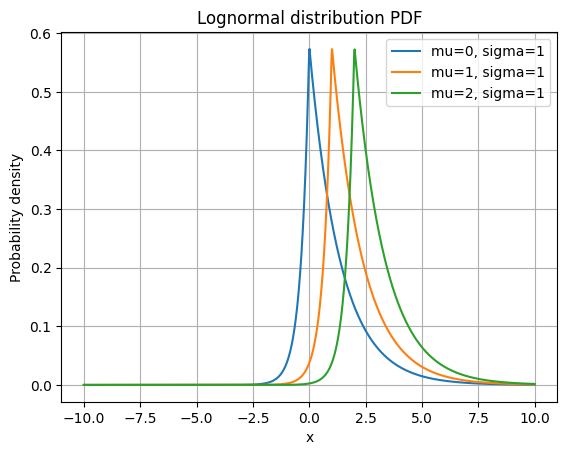

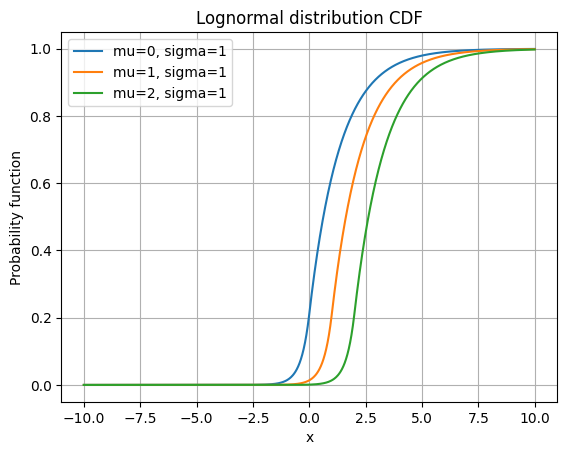

In [76]:
x: np.ndarray = np.linspace(-10, 10, 1000)

for i in MU_ARR:
    distr = VarianceGamma(i, THETA, SIGMA, NU)
    y = distr.pdf(x)
    plt.plot(x, y, label=f"mu={i}, sigma={SIGMA}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Lognormal distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in MU_ARR:
    distr = VarianceGamma(i, THETA, SIGMA, NU)
    y = distr.cdf(x)
    plt.plot(x, y, label=f"mu={i}, sigma={SIGMA}")
plt.xlabel("x")
plt.ylabel("Probability function")
plt.title("Lognormal distribution CDF")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: с увеличением параметра $\mu$ самая мода смещается вправо и становится ниже. Сам график становится более пологим.
2. Функция распределения: точка перегиба с увеличением $\mu$ смещается вправо и функция возрастает намого медленнее.

Зафиксируем $\mu=1$ и рассмотрим три значения $\sigma = 0, 1, 2$. Построим плотности и функции распределения:

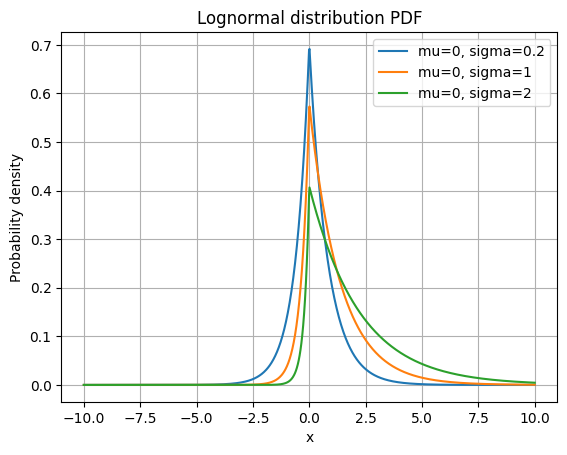

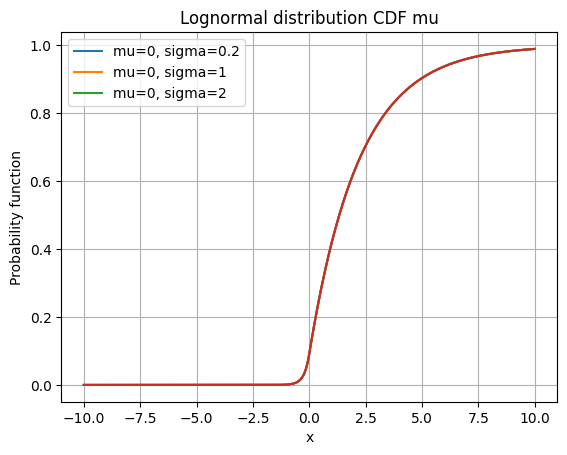

In [77]:
x: np.ndarray = np.linspace(-10, 10, 1000)

for i in SIGMA_ARR:
    distr = VarianceGamma(MU, i, SIGMA, NU)
    y = distr.pdf(x)
    plt.plot(x, y, label=f"mu={MU}, sigma={i}")
plt.xlabel("x")
plt.ylabel("Probability density")
plt.title("Lognormal distribution PDF")
plt.grid(True)
plt.legend()
plt.show()

for i in SIGMA_ARR:
    lognorm_distr = VarianceGamma(MU, i, SIGMA, NU)
    y = distr.cdf(x)
    plt.plot(x, y, label=f"mu={MU}, sigma={i}")
plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("Probability function")
plt.title("Lognormal distribution CDF mu")
plt.grid(True)
plt.legend()
plt.show()

Вывод: 
1. Плотность: при небольших параметрах $\sigma$ распределение близко к нормальному, но имеет небольшой скок влево. При $sigma=1$ мода смещается левее и становится ниже, распределение становится более ассимметричным, правый хвост удлиняется. При больших $sigma$ мода смещается ещё левее, большая часть зачений сосредоточена возле нуля. Пик низкий и широкий.
2. Функция распределения: с увеличением $sigma$ подъём графика становится медленнее

## 3. Моделирование случайной выборки. Точность моделирования (критерии). Алгоритм моделирования.

Алгоритм:
1. Генерируются случайные величины, имеющие нормальное распределение при помощи второго варианта алгортма Бокса-Мюллера.
2. Берётся логарифм от этих случайных величин.

Используются два статистических критерия: $\Chi_2$-критерий и критерий Шапиро-Уилка. Посколько критерий Шапиро-Уилка используется только для нормального распределения, в нём используется прологарифмированная выборка

In [78]:
distr = VarianceGamma(MU, THETA, SIGMA, NU)

sample = distr.rvs(1000)

x = np.linspace(min(sample), max(sample), 1000)
y = [distr.pdf(i) for i in x]

y_cdf = distr.cdf(x)
ks_stat, ks_p_value = stats.kstest(sample, y_cdf)
print(f"Kolmogorov-Smirnov test: statistic={ks_stat}, p-value={ks_p_value}")

Kolmogorov-Smirnov test: statistic=0.376, p-value=2.5116988010361783e-63


## 4. Оценка параметров распределения. Точность оценивания (критерии).

Параметрами распределения являются математическое ожидание и стандартное нормальное отклонение, находятся их оценки.

In [79]:
print(f"Estimated mean: {np.mean(sample)}")
print(f"Estimated variance: {np.var(sample)}")

Estimated mean: 0.9744288360399944
Estimated variance: 1.9277377075946829


## 5. Оценка плотности распределения

Для оценки плотности распределения используется ядерная оценка с гауссовским ядром.

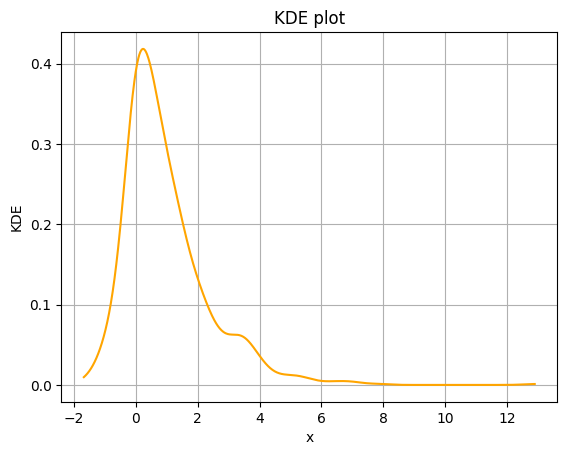

In [85]:
kde = stats.gaussian_kde(sample)
density = kde.evaluate(x)

plt.plot(x, density, color="orange")
plt.xlabel("x")
plt.ylabel("KDE")
plt.title("KDE plot")
plt.grid()
plt.show()

## 6. На одном графике: плотность распределения, гистограмма и оценка плотности распределения

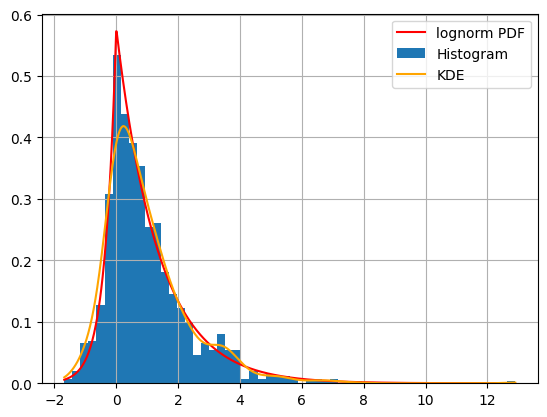

In [86]:
x = np.linspace(min(sample), max(sample), 1000)
pdf = distr.pdf(x)

num_bins = math.trunc(max(sample) - min(sample)) * 4

plt.plot(x, pdf, color="red", label="lognorm PDF")
plt.hist(sample, bins=num_bins, density=True, label="Histogram")
plt.plot(x, density, color="orange", label="KDE")

plt.grid()
plt.legend()
plt.show()

## 7. Исследовать квантиль распределения в зависимости от параметров распределения. Вычислить VaR.

Зафиксируем $\sigma=1$. Построим график зависимости квантиля распределения от $\mu$. Возьмём $p=0.95$

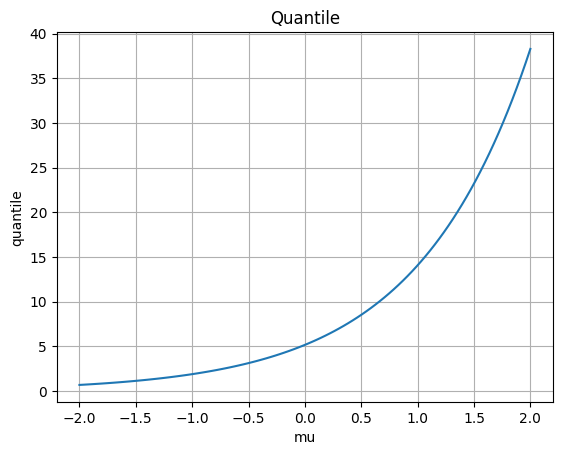

In [87]:
p = 0.95
mu_values = np.linspace(-2, 2, 100)
q = np.exp(mu_values + SIGMA * stats.norm.ppf(p))
plt.plot(mu_values, q)
plt.xlabel("mu")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Зафиксируем $\mu=0$. Построим график зависимости квантиля распределения от $\sigma$. Возьмём $p=0.95$

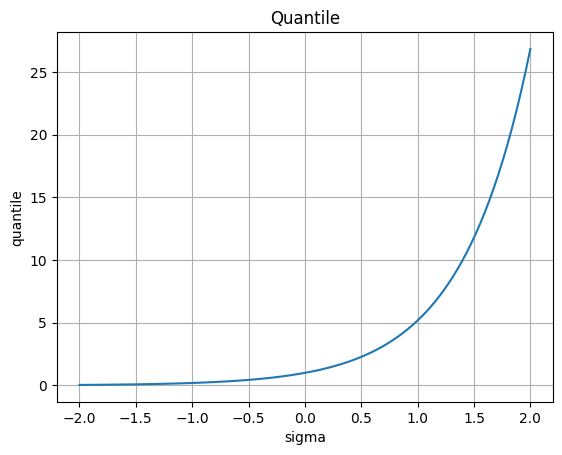

In [88]:
p = 0.95
sigma_values = np.linspace(-2, 2, 100)
q = np.exp(MU + sigma_values * stats.norm.ppf(p))
plt.plot(sigma_values, q)
plt.xlabel("sigma")
plt.ylabel("quantile")
plt.grid()
plt.title("Quantile")
plt.show()

Вычислим VaR:

In [84]:
# Уровни доверия для VaR (левосторонние квантили, т.е. вероятность не превысить)
levels = [0.95, 0.99]

# Теоретические квантили с истинными параметрами
var_true = [np.exp(MU + SIGMA * stats.norm.ppf(p)) for p in levels]
print("VaR (истинные параметры):")
for p, var in zip(levels, var_true):
    print(f"  VaR_{p*100:.0f}% = {var:.4f}")

# Теоретические квантили с оценёнными параметрами
var_mle = [np.exp(np.mean(sample_logged) + np.std(sample_logged) * stats.norm.ppf(p)) for p in levels]
print("\nVaR (оценённые параметры MLE):")
for p, var in zip(levels, var_mle):
    print(f"  VaR_{p*100:.0f}% = {var:.4f}")

VaR (истинные параметры):
  VaR_95% = 5.1803
  VaR_99% = 10.2405

VaR (оценённые параметры MLE):
  VaR_95% = nan
  VaR_99% = nan
